In [24]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [25]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [26]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205_fillna.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet

Error: path "/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_
251205.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_
251205_fillna.parquet" already exists but -f/--overwrite was not set


In [27]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        core_promoter = pl.col('dist_to_tss').abs() <= 50,
        encode_annotated = pl.col('not_in_encode') == False,
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

encode_tf,loftee_lc,verphylop,consequence_missense_variant,gene_length,absplice_dna_max,ted_domain,delta_score,encode_pls,gpn_star_llr_calibrated_mean,encode_dels,encode_ca_tf,esmscoremissense,loftee_lip,absplice2_max,abexp_abs_max,pangolin_score,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,consequence_synonymous_variant,consequence_splice_donor_variant,loftee_low_complexity,loftee_ted,id,dist_to_tss,consequence_stop_gained,score_pai3d,five_prime_utr_variant_consequence_ustop_gained,cadd_raw,gpn_score,am_pathogenicity,gene_name,loftee_hc,strand,consequence_frameshift_variant,consequence_stop_lost,encode_eh_pr,consequence_splice_acceptor_variant,promoterai,mobi_lip_full,tss,mobi_curated_disorder_priority,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,encode_pels,loftee_disorder,region,low_complexity_domain
bool,i8,f32,i32,i64,f32,bool,f32,bool,f32,bool,bool,f32,bool,f32,f32,f32,i32,u8,i32,i32,bool,bool,str,i64,i32,f32,u8,f32,f32,f32,str,i8,str,i32,i32,bool,i32,f32,bool,i64,bool,u8,u8,bool,bool,str,bool
false,0,9.133,1,26121,0.29,false,0.87,false,-9.52998,true,false,-6.781,false,0.531172,1.997105,0.82,0,0,0,0,false,false,"""chr15:64859998:G:C""",18116,0,0.626882,0,6.585388,-12.04,0.6981,"""PLEKHO2""",0,"""1""",0,0,true,0,0.0,true,64841882,false,0,0,false,false,"""ENSG00000241839""",false
false,0,4.968,1,83994,0.001,false,0.0,false,-6.822783,false,false,-3.949,false,0.000074,0.049098,0.0,0,0,0,0,false,false,"""chr1:202729885:A:T""",78602,0,0.602516,0,2.497457,-8.92,0.0911,"""KDM5B""",0,"""-1""",0,0,false,0,-0.0028,true,202808487,true,0,0,false,false,"""ENSG00000117139""",true
false,0,3.389,1,9354,0.003,true,0.0,false,-7.618337,false,false,-12.142,false,0.000395,0.078567,0.0,0,0,0,0,false,false,"""chr11:125672628:A:G""",8246,0,0.758137,0,4.886163,-6.64,0.9957,"""ACRV1""",0,"""-1""",0,0,false,0,0.0,false,125680874,false,0,0,false,false,"""ENSG00000134940""",false
false,0,-0.317,1,83994,0.003,false,0.0,false,-1.582607,true,false,-3.762,false,0.000341,0.026393,0.0,0,0,0,0,false,false,"""chr1:202742800:C:T""",65687,0,0.254022,0,1.024761,-2.59,0.0651,"""KDM5B""",0,"""-1""",0,0,true,0,0.0,false,202808487,false,0,0,false,false,"""ENSG00000117139""",false
false,0,2.362,1,83994,0.003,false,0.0,false,-3.622938,false,false,-3.944,false,0.000369,0.07843,0.0,0,0,0,0,false,false,"""chr1:202735550:A:G""",72937,0,0.412907,0,2.466337,-5.7,0.0902,"""KDM5B""",0,"""-1""",0,0,false,0,0.0,false,202808487,true,0,0,false,false,"""ENSG00000117139""",false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,0,1.203,0,26395,0.005817,true,0.01,false,0.031151,false,false,0.0,false,0.000663,0.03127,0.01,0,0,1,0,false,false,"""chr2:43825007:T:C""",13858,0,0.0,0,0.59692,-2.25,0.0,"""ABCG5""",0,"""-1""",0,0,false,0,0.0,false,43838865,false,0,0,false,false,"""ENSG00000138075""",false
false,0,7.101,1,69956,0.00291,true,0.0,false,-7.166539,false,false,-6.958,false,0.000348,0.089759,0.0,0,0,0,0,false,false,"""chr10:99819216:C:A""",36577,0,0.741718,0,4.454148,-8.51,0.4961,"""ABCC2""",0,"""1""",0,0,false,0,0.0,false,99782639,false,0,0,false,false,"""ENSG00000023839""",false
false,0,8.683,1,69956,0.009023,false,0.08,false,-6.454949,false,false,-4.605,false,0.002292,0.1407,0.02,0,0,0,0,false,false,"""chr10:99800490:A:T""",17851,0,0.77205,0,4.481823,-7.68,0.4567,"""ABCC2""",0,"""1""",0,0,false,0,0.0,false,99782639,false,0,0,false,false,"""ENSG00000023839""",false


In [28]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['vep_consequences']) # VEP CDS consequences
    # pl.col('category').is_in(['plof_consequences']) # VEP plof consequences
    (pl.col('category').is_in(['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'])) # CDS
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation'])) # missense
    # (pl.col('category').is_in(['protein_domains'])) # protein domains
    # (pl.col('category').is_in(['loftee_protein_domains'])) # protein domains
    # (pl.col('category').is_in(['splicing', 'genetic_diversity', 'conservation'])) # synonymous

    # (pl.col('category').is_in(['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'])) # non coding
    # (pl.col('category').is_in(['encode_regions'])) # encode regions
    # (pl.col('category').is_in(['encode_custom'])) # encode regions custom
    # (pl.col('category').is_in(['conservation', 'regulatory_nondir', 'genetic_diversity'])) # 5UTR
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr15:64859998:G:C""","""ENSG00000241839""","""loftee_hc""",0.0
"""chr1:202729885:A:T""","""ENSG00000117139""","""loftee_hc""",0.0
"""chr11:125672628:A:G""","""ENSG00000134940""","""loftee_hc""",0.0
"""chr1:202742800:C:T""","""ENSG00000117139""","""loftee_hc""",0.0
"""chr1:202735550:A:G""","""ENSG00000117139""","""loftee_hc""",0.0
…,…,…,…
"""chr2:43825007:T:C""","""ENSG00000138075""","""abexp_abs_max""",0.03127
"""chr10:99819216:C:A""","""ENSG00000023839""","""abexp_abs_max""",0.089759
"""chr10:99800490:A:T""","""ENSG00000023839""","""abexp_abs_max""",0.1407


In [29]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [30]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

if pheno_list_type is not None:
    gene_trait_df = gene_trait_df.filter(pl.col('phenotype').is_in(pheno_list))

gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [31]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(352, 1176)

In [32]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")

    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')

Executing the full lazy plan with the streaming engine...


In [ ]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_mac20.parquet -o /home/dnanexus/data_dir/association_files/

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_mac20.parquet')
    .select(['region', 'phenotype', 'loftee_correlation', 'loftee_corr_dir']) 
)

loftee_corrs

In [11]:
# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    correlation_df
    .filter(pl.col('annotation')!='loftee_hc')
    .select(["region", "gene_name", "phenotype", "annotation", "n_variants", "correlation"])
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        loftee_corrs, 
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_correlation'))*pl.col('loftee_corr_dir')
    )
)
print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (14112, 13)


region,gene_name,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,loftee_correlation,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64
"""ENSG00000166603""","""MC4R""","""body_mass_index_bmi_int""","""gpn_star_llr_calibrated_mean""",203,-0.194587,"""#942c80""","""GPN-Star""",-1,0.166278,1.0,0.194587,1.170248
"""ENSG00000241119""","""UGT1A9""","""total_bilirubin_int""","""am_pathogenicity""",396,0.204513,"""#feb72d""","""AlphaMissense""",1,0.077977,1.0,0.204513,2.62273
"""ENSG00000080345""","""RIF1""","""leg_fat_percentage_left_int""","""abexp_abs_max""",1624,0.034294,"""#80CBC4""","""AbExp abs max""",1,0.041121,1.0,0.034294,0.833989
"""ENSG00000084674""","""APOB""","""hdl_cholesterol_int""","""score_pai3d""",2745,NaN,"""#feb72d""","""PrimateAI-3D""",1,0.073819,1.0,NaN,NaN
"""ENSG00000100281""","""HMGXB4""","""forced_vital_capacity_fvc_int""","""absplice_dna_max""",364,-0.092554,"""#28a745""","""AbSplice (max)""",1,-0.146098,-1.0,0.092554,0.633505
…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000106853""","""PTGR1""","""monocyte_percentage_int""","""verphylop""",249,-0.097389,"""#942c80""","""Vertebrate PhyloP""",1,0.015566,1.0,-0.097389,-6.256572
"""ENSG00000198858""","""R3HDM4""","""reticulocyte_count_int""","""abexp_abs_max""",350,0.034808,"""#80CBC4""","""AbExp abs max""",1,0.0373,1.0,0.034808,0.933172
"""ENSG00000196712""","""NF1""","""standing_height_int""","""score_pai3d""",1673,NaN,"""#feb72d""","""PrimateAI-3D""",1,-0.104759,-1.0,NaN,NaN


In [12]:
# correlation_df.write_parquet(f'/home/dnanexus/data_dir/results/correlations_all_vars_wgs_EUR_genebass1e6_maf1e3.parquet')
# correlation_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/correlations_all_vars_wgs_EUR_genebass1e6_maf1e3.parquet')

In [13]:

consistent_gt = (
    correlation_df
    # .filter(pl.col('annotation')!='promoterai_abs')
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name', 'phenotype'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)  # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'gene_name', 'phenotype'], how='inner')
filt_corr_df

region,gene_name,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,loftee_correlation,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,u64
"""ENSG00000166603""","""MC4R""","""body_mass_index_bmi_int""","""gpn_star_llr_calibrated_mean""",203,-0.194587,"""#942c80""","""GPN-Star""",-1,0.166278,1.0,0.194587,1.170248,12
"""ENSG00000241119""","""UGT1A9""","""total_bilirubin_int""","""am_pathogenicity""",396,0.204513,"""#feb72d""","""AlphaMissense""",1,0.077977,1.0,0.204513,2.62273,12
"""ENSG00000080345""","""RIF1""","""leg_fat_percentage_left_int""","""abexp_abs_max""",1624,0.034294,"""#80CBC4""","""AbExp abs max""",1,0.041121,1.0,0.034294,0.833989,12
"""ENSG00000100281""","""HMGXB4""","""forced_vital_capacity_fvc_int""","""absplice_dna_max""",364,-0.092554,"""#28a745""","""AbSplice (max)""",1,-0.146098,-1.0,0.092554,0.633505,12
"""ENSG00000162337""","""LRP5""","""heel_bone_mineral_density_bmd_…","""gpn_star_llr_calibrated_mean""",913,0.142029,"""#942c80""","""GPN-Star""",-1,-0.087678,-1.0,0.142029,1.619896,12
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000118762""","""PKD2""","""urea_int""","""abexp_abs_max""",630,0.060892,"""#80CBC4""","""AbExp abs max""",1,0.098274,1.0,0.060892,0.619608,12
"""ENSG00000117724""","""CENPF""","""forced_expiratory_volume_in_1s…","""am_pathogenicity""",1409,0.025625,"""#feb72d""","""AlphaMissense""",1,-0.012184,-1.0,-0.025625,-2.103142,12
"""ENSG00000106853""","""PTGR1""","""monocyte_percentage_int""","""verphylop""",249,-0.097389,"""#942c80""","""Vertebrate PhyloP""",1,0.015566,1.0,-0.097389,-6.256572,12


In [14]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


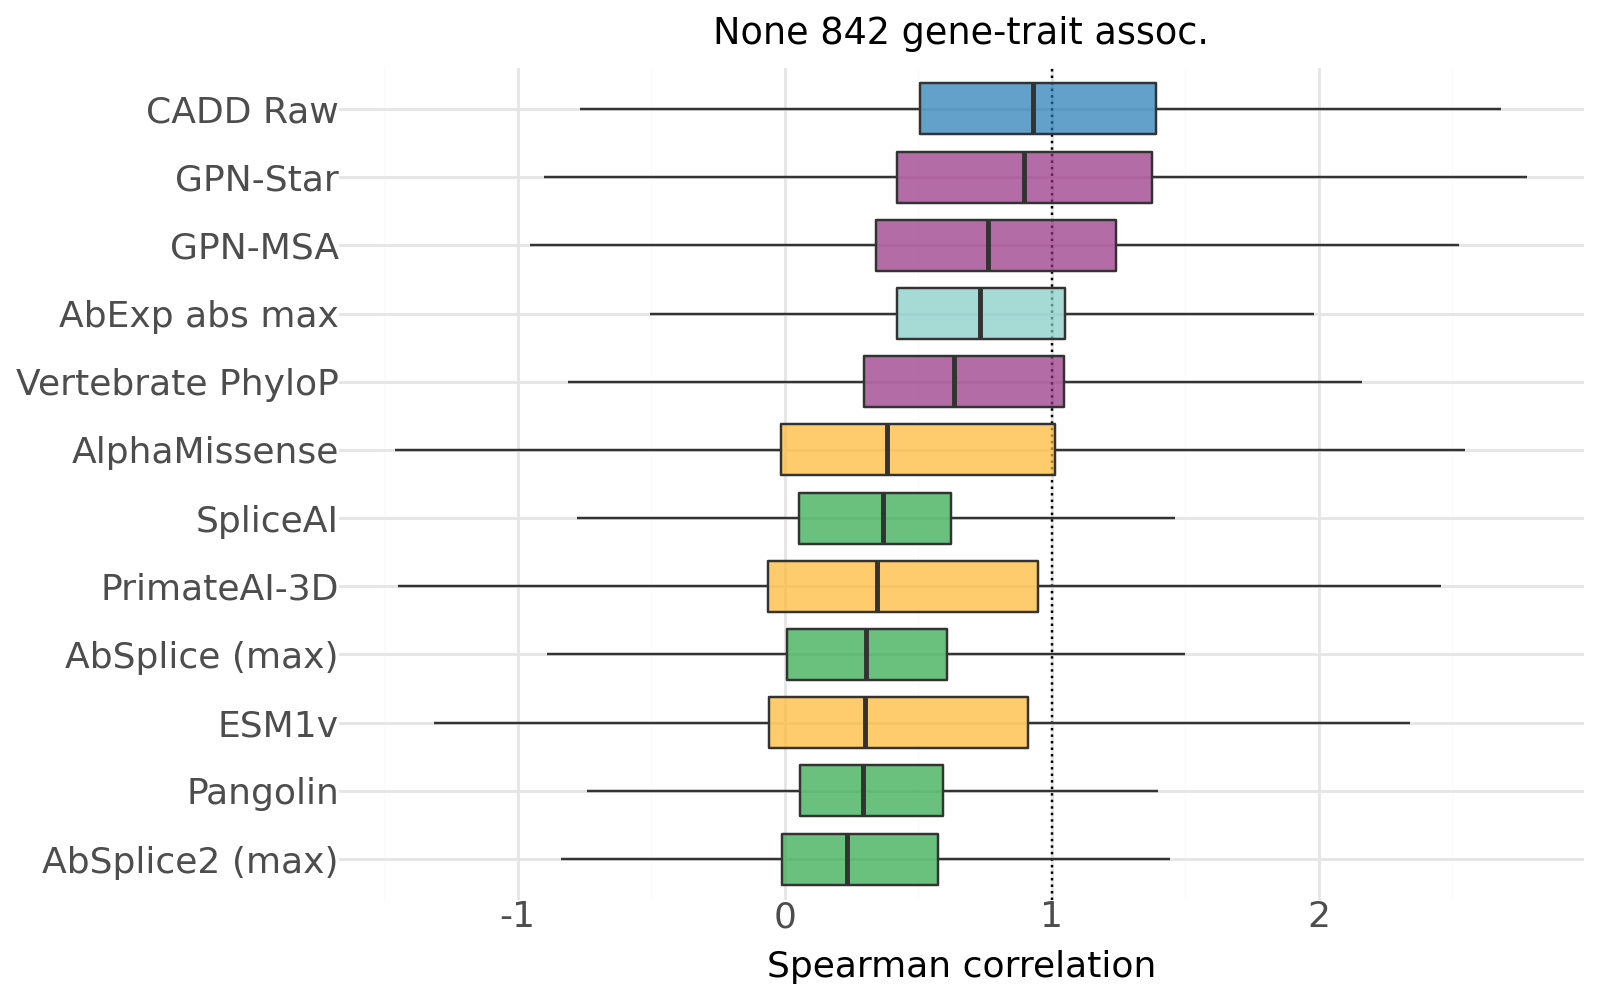

In [22]:
# Prepare for plotting
med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta_rescaled = pl.col("corr_beta_rescaled").median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta_rescaled', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta_rescaled", fill="annotation"))
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{pheno_list_type} {corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc."
        # \nGene body ±5kb"
        # \n VEP CDS variants"
        # \n Disorder region missense variants"
        # \n{variant_class} variants"
        # \nTSS [{min_range}bp, {max_range}bp]"
    )
    + coord_flip()
    + theme(
        figure_size=(8, 5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [16]:
med_df.sort('median_corr_beta_rescaled')

annotation,median_corr_beta_rescaled
str,f64
"""absplice2_max""",0.233907
"""pangolin_score""",0.294859
"""esmscoremissense""",0.30111
"""absplice_dna_max""",0.304183
"""score_pai3d""",0.344745
…,…
"""verphylop""",0.633392
"""abexp_abs_max""",0.73283
"""gpn_score""",0.761744


In [17]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_213391/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""cadd_raw""","""esmscoremissense""",842,8429.0,1.0904e-126
"""cadd_raw""","""am_pathogenicity""",842,10560.0,1.4529e-123
"""cadd_raw""","""score_pai3d""",842,11247.0,1.4493e-122
"""gpn_star_llr_calibrated_mean""","""esmscoremissense""",842,14472.0,6.2446e-118
"""gpn_star_llr_calibrated_mean""","""score_pai3d""",842,15487.0,1.7193e-116
…,…,…,…,…
"""score_pai3d""","""pangolin_score""",842,158852.0,0.00842
"""absplice_dna_max""","""esmscoremissense""",842,160432.0,0.015912
"""absplice_dna_max""","""absplice2_max""",842,160412.0,0.018358


In [18]:
stats_df.filter(
    (pl.col('VSM_A') == 'absplice2_max') | (pl.col('VSM_B') == 'absplice2_max')
)

VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""verphylop""","""absplice2_max""",842,80777.0,1.0944e-42
"""delta_score""","""absplice2_max""",842,152852.0,0.000601
"""gpn_score""","""absplice2_max""",842,57859.0,2.2417e-64
"""cadd_raw""","""absplice2_max""",842,37039.0,4.9366e-88
"""gpn_star_llr_calibrated_mean""","""absplice2_max""",842,45642.0,8.4221e-78
…,…,…,…,…
"""absplice_dna_max""","""absplice2_max""",842,160412.0,0.018358
"""score_pai3d""","""absplice2_max""",842,150531.0,0.000137
"""absplice2_max""","""pangolin_score""",842,153622.0,0.000894
